<a href="https://colab.research.google.com/github/Yugansh-Varshney/ANN-Classification-Churn-Prediction-Model/blob/main/MNIST_Digit_Classification_Simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handwritten Digit Recognition with a Neural Network

In this notebook, we will build a simple neural network that can look at an image of a handwritten digit (0–9) and correctly identify which digit it is.

We will use the **MNIST dataset** — a collection of 70,000 grayscale images of handwritten digits, each 28x28 pixels.

By the end of this notebook, you will understand:

- How an image can be turned into numbers a neural network can process
- How a network is structured in layers, and what activation functions do at each layer
- How the network learns through forward propagation and backpropagation
- How to check whether the model actually learned something useful


## 1. Importing Libraries


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Loading the Dataset

MNIST is already built into Keras, so we don't need to download or clean anything. It comes pre-split into a training set and a test set.

- `x_train`, `x_test`: the images (pixel values)
- `y_train`, `y_test`: the correct labels (the digit each image represents, 0–9)


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images shape:", x_train.shape)
print("Test images shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Test images shape: (10000, 28, 28)


## 3. Looking at the Data

Each image is a 28x28 grid of pixel values, ranging from 0 (black) to 255 (white). Let's look at a few examples.


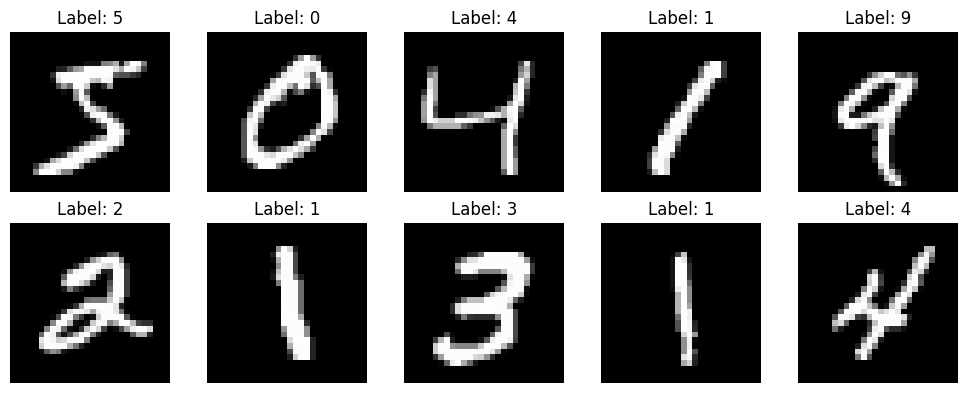

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## 4. Preparing the Data

A neural network needs numeric input in a simple, consistent format. We do two things:

**a) Normalize pixel values.** Pixel values range from 0 to 255. We divide by 255 so every value falls between 0 and 1. This helps the network train faster and more smoothly.

**b) Flatten the images.** Our images are 28x28 2D grids, but a plain (dense) neural network expects a 1D list of numbers as input. So we "unroll" each 28x28 image into a single row of 784 numbers (28 × 28 = 784). Each of those 784 numbers becomes one input to the network — literally one input neuron per pixel.

We keep the labels as they are (plain numbers 0–9) and use a loss function later that can handle that directly, so no extra encoding step is needed.


In [4]:
# Normalize pixel values to the range [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Flatten each 28x28 image into a vector of 784 numbers
x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], 28 * 28)
x_test_flat = x_test_norm.reshape(x_test_norm.shape[0], 28 * 28)

print("Flattened training data shape:", x_train_flat.shape)
print("Flattened test data shape:", x_test_flat.shape)


Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


## 5. Building the Neural Network

Now we design the network, layer by layer:

- **Input layer:** 784 neurons — one for each pixel in the flattened image.
- **Hidden layer:** 32 neurons that learn to detect patterns in the pixels that are useful for telling digits apart. We use the **ReLU** activation function here — it simply outputs the input directly if it's positive, and 0 otherwise. ReLU is the most common choice for hidden layers because it's simple and trains well.
- **Output layer:** 10 neurons — one for each possible digit (0–9). We use the **Softmax** activation function here, which turns the raw outputs into a probability for each digit, all adding up to 1. The digit with the highest probability is the network's prediction.

This is a small, single-hidden-layer network — enough to see the core ideas in action without a lot of extra complexity.


In [5]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,450 (99.41 KB)

 Trainable params: 25,450 (99.41 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compiling the Model

Before training, we define three things:

- **Loss function:** `sparse_categorical_crossentropy` — measures how far off the network's predicted probabilities are from the true label. Training tries to make this value as small as possible.
- **Optimizer:** `adam` — the algorithm that performs **backpropagation** and updates the network's weights. It works out how much each weight contributed to the error, then adjusts every weight a small step in the direction that reduces the loss.
- **Metric:** `accuracy` — the percentage of images classified correctly. This is what we use to judge performance.


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## 7. Training the Model

This is where **forward propagation** and **backpropagation** happen, repeatedly:

1. **Forward pass:** A batch of images is fed through the network to produce a prediction.
2. **Loss calculation:** The prediction is compared to the true label using the loss function.
3. **Backward pass (backpropagation):** The error is sent backward through the network, working out how much each weight contributed to it.
4. **Weight update:** Each weight is nudged slightly in the direction that reduces the error.

This repeats for every batch, across several **epochs** (full passes through the training data).


In [7]:
history = model.fit(
    x_train_flat, y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8516 - loss: 0.5530 - val_accuracy: 0.9380 - val_loss: 0.2373
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9277 - loss: 0.2549 - val_accuracy: 0.9495 - val_loss: 0.1912
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9396 - loss: 0.2131 - val_accuracy: 0.9547 - val_loss: 0.1667
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9473 - loss: 0.1851 - val_accuracy: 0.9558 - val_loss: 0.1531
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9524 - loss: 0.1649 - val_accuracy: 0.9610 - val_loss: 0.1400
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9564 - loss: 0.1477 - val_accuracy: 0.9630 - val_loss: 0.1344
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9611 - loss: 0.1341 - val_accuracy: 0.9653 - val_loss: 0.1246
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9647 - loss: 0.1222 - val_accuracy: 0.9647 - v

## 8. Visualizing Training Progress

Let's plot how accuracy and loss changed across epochs.


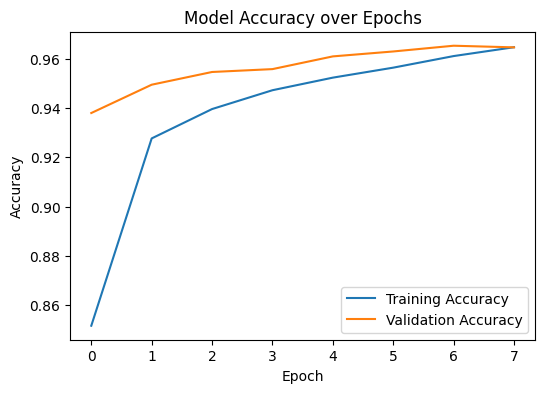

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## 9. Evaluating on Test Data

The test set was never seen during training, so this tells us how well the model does on new, unseen digits.


In [9]:
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.1355
Test Accuracy: 0.9593


## 10. Trying It on Some Test Images

Let's look at a few test images side by side with what the model predicted.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


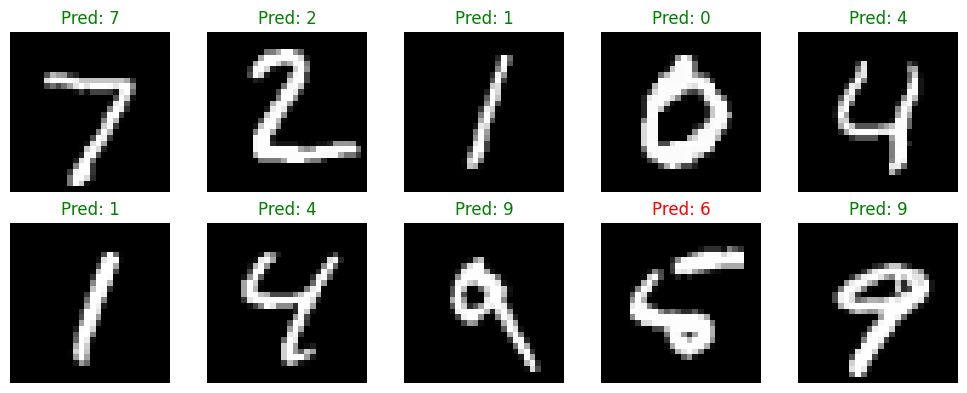

In [10]:
predictions = model.predict(x_test_flat[:10])
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    color = 'green' if predicted_labels[i] == y_test[i] else 'red'
    plt.title(f"Pred: {predicted_labels[i]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()


## 11. Summary

In this notebook, we built a small, fully-connected (dense) neural network that classifies handwritten digits.

Along the way, we covered:

- **Data preparation:** normalizing pixel values and flattening images into vectors
- **Network architecture:** an input layer, one hidden layer with ReLU activation, and a softmax output layer
- **Forward propagation:** how input data flows through the network to produce a prediction
- **Backpropagation:** how the network calculates error and updates its weights to improve
- **Evaluation:** checking accuracy and looking at predictions on real test images

### Things to try next
- Change the number of neurons in the hidden layer (try 16, or 64). Does it change accuracy much?
- Add a second hidden layer. Does the model do better?
- Try a different activation function (like `tanh` or `sigmoid`) in the hidden layer and compare results.
- Change the number of epochs. What happens if you train for longer or shorter?
